# Model Construction Notebook

These are the selection models I will build: KNN, Decision Tree, Logistic Regression, Major voting. This combination represents a mix of linear, non-linear, and ensemble approaches.
All models are trained using all standardized 30 features.

Each model will be evaluated on: Validation accuracy, Test accuracy, Precision, Recall, F1 score, ROC curve and AUC, Confusion matrix.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

## Split data into X-features and y-labels

In [2]:
train_data_df = pd.read_csv("../data/train/train.csv")
test_data_df = pd.read_csv("../data/test/test.csv")
val_data_df = pd.read_csv("../data/val/val.csv")

X_train_data = train_data_df.drop(columns=["Diagnosis"]).to_numpy()
y_train_data = train_data_df["Diagnosis"].to_numpy()

X_test_data = test_data_df.drop(columns=["Diagnosis"]).to_numpy()
y_test_data = test_data_df["Diagnosis"].to_numpy()

X_val_data = val_data_df.drop(columns=["Diagnosis"]).to_numpy()
y_val_data = val_data_df["Diagnosis"].to_numpy()

In [3]:
X_train_data.shape, X_val_data.shape, X_test_data.shape

((398, 30), (85, 30), (86, 30))

In [4]:
# Helper Function
def model_evaluation(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    print(f"\n{name}")

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
    print("Validation Recall:", recall_score(y_val, y_val_pred))
    print("Validation Precision:", precision_score(y_val, y_val_pred))
    print("Validation F1:", f1_score(y_val, y_val_pred))

    print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Test Recall:", recall_score(y_test, y_test_pred))
    print("Test Precision:", precision_score(y_test, y_test_pred))
    print("Test F1:", f1_score(y_test, y_test_pred))

    return model, y_val_pred, y_test_pred


## Models Implementation
### 1. KNN

In [5]:
knn = KNeighborsClassifier(
    n_neighbors = 5,
    weights="distance",
    metric="minkowski")
knn, knn_val_prediction, knn_test_prediction= model_evaluation("KNN", knn, X_train_data, y_train_data, X_val_data, y_val_data,
                       X_test_data, y_test_data)


KNN
Validation Accuracy: 0.9647058823529412
Validation Recall: 0.90625
Validation Precision: 1.0
Validation F1: 0.9508196721311475

Test Accuracy: 0.9651162790697675
Test Recall: 0.90625
Test Precision: 1.0
Test F1: 0.9508196721311475


### 2. Decision Tree

In [6]:
dt = DecisionTreeClassifier(
    max_depth=None,     
    random_state=42
)

dt, dt_val_prediction, dt_test_prediction = model_evaluation("Decision Tree", dt,
    X_train_data, y_train_data,
    X_val_data,   y_val_data,
    X_test_data,  y_test_data
)



Decision Tree
Validation Accuracy: 0.8941176470588236
Validation Recall: 0.8125
Validation Precision: 0.896551724137931
Validation F1: 0.8524590163934426

Test Accuracy: 0.9069767441860465
Test Recall: 0.875
Test Precision: 0.875
Test F1: 0.875


### 3. Logistic Regression

In [7]:

Lg = LogisticRegression(
    solver="liblinear",
    max_iter=500,
    random_state=42
)
Lg, Lg_val_prediction, Lg_test_prediction= model_evaluation("Lg", Lg, X_train_data, y_train_data, X_val_data, y_val_data,
                       X_test_data, y_test_data)


Lg
Validation Accuracy: 0.9647058823529412
Validation Recall: 0.90625
Validation Precision: 1.0
Validation F1: 0.9508196721311475

Test Accuracy: 0.9767441860465116
Test Recall: 0.96875
Test Precision: 0.96875
Test F1: 0.96875


### 4. Majority Voting Classifier

In [8]:
lr_vote = LogisticRegression(max_iter=500, solver="liblinear", random_state=42)
knn_vote = KNeighborsClassifier(n_neighbors=5, weights="distance")
dt_vote = DecisionTreeClassifier(random_state=42)
voting_cls = VotingClassifier(
    estimators=[
        ("LR", lr_vote), ("KNN", knn_vote), ("DT", dt_vote)], voting = "soft")
voting_cls, voting_val_prediction, voting_test_prediction = model_evaluation(
    "Majority Voting", voting_cls, X_train_data, y_train_data, X_val_data, y_val_data,
                       X_test_data, y_test_data)


Majority Voting
Validation Accuracy: 0.9411764705882353
Validation Recall: 0.875
Validation Precision: 0.9655172413793104
Validation F1: 0.9180327868852459

Test Accuracy: 0.9651162790697675
Test Recall: 0.90625
Test Precision: 1.0
Test F1: 0.9508196721311475


## ROC metric to access models performance

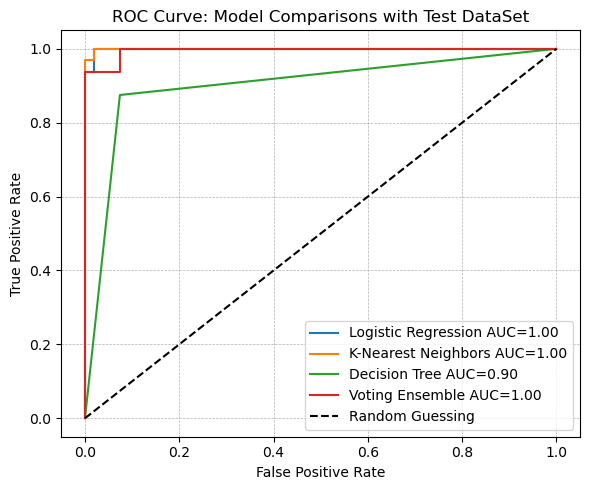

In [9]:
models = [
    ("Logistic Regression", Lg),
    ("K-Nearest Neighbors", knn),
    ("Decision Tree", dt),
    ("Voting Ensemble", voting_cls)
]

plt.figure(figsize=(6, 5))

for name, model in models:
    probabilities = model.predict_proba(X_test_data) 
    y_prob = probabilities[:, 1] 

  
    fpr, tpr, _ = roc_curve(y_test_data, y_prob, pos_label=1)


    auc = roc_auc_score(y_test_data, y_prob)

    label = name + ' AUC='+'{:.2f}'.format(auc)

   
    plt.plot(fpr, tpr, label = label)


plt.plot([0, 1], [0, 1], "k--", label="Random Guessing")

plt.grid(linestyle="--", linewidth=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Model Comparisons with Test DataSet")
plt.legend()
plt.tight_layout()
plt.show()

## Confusion metric to plot the each model's classification

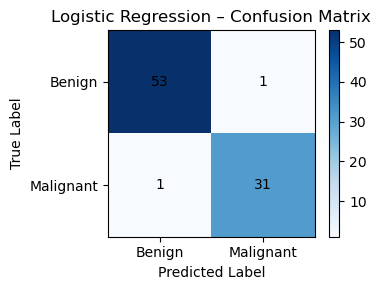

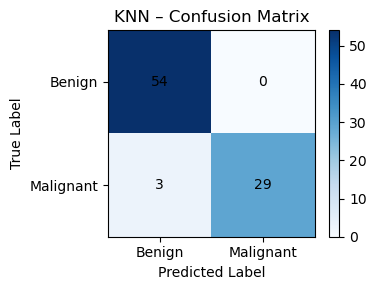

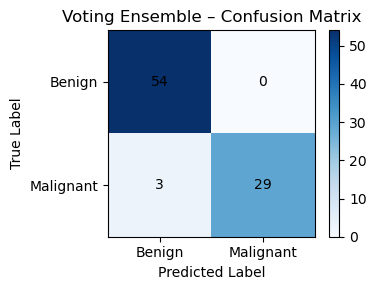

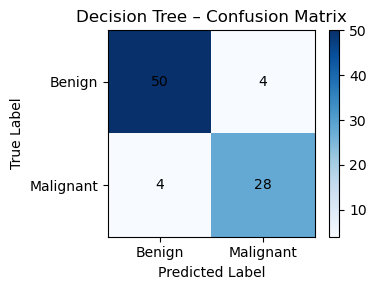

In [12]:
def plot_conf_mat(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4,3))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]), ha="center", va="center", color="black")
            
    plt.xticks([0,1], ["Benign", "Malignant"])
    plt.yticks([0,1], ["Benign", "Malignant"])
    plt.colorbar()
    plt.tight_layout()
    plt.show()


plot_conf_mat(y_test_data, Lg_test_prediction, "Logistic Regression – Confusion Matrix")
plot_conf_mat(y_test_data, knn_test_prediction, "KNN – Confusion Matrix")
plot_conf_mat(y_test_data, voting_test_prediction, "Voting Ensemble – Confusion Matrix")
plot_conf_mat(y_test_data, dt_test_prediction, "Decision Tree – Confusion Matrix")


### Outcome of All Model Evaluation
Although several models obtained AUC = 1.0, Logistic Regression:
Achieved the highest test accuracy (97.67%)\
Achieved the highest recall (0.9688)\
Had the best F1-score (0.9688)

Based on the confusion matrices, Logistic Regression misclassifies only one malignant tumor, whereas KNN and Major voting misclassify three and Decision Tree misclassifies even more. Since false negatives are critical in medical diagnosis, Logistic Regression provides the most reliable performance.